<a href="https://colab.research.google.com/github/Pranav77774/concept-and-technology-of-AI/blob/main/2501565_PranavManSingh_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install & Import Libraries
!pip install -q scikit-learn==1.3.2 matplotlib pandas seaborn tensorflow==2.15.0 joblib

# Imports
import os
import math
import json
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (9,6)

# sklearn & tensorflow
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.inspection import permutation_importance

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Imports complete. ", tf.__version__)


ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.15.0
Imports complete.  2.20.0


In [ ]:
# Load Dataset & Save Provenance
csv_path = "/content/drive/MyDrive/Student_Performance.csv"

if not os.path.exists(csv_path):
    print("Dataset not found at", csv_path)
    try:
        from google.colab import files
        uploaded = files.upload()
        csv_path = list(uploaded.keys())[0]
    except ImportError:
        raise SystemExit(f"Please place '{csv_path}' in the working directory, or update csv_path.")

df = pd.read_csv(csv_path)
print("Loaded file:", csv_path)
print("Shape:", df.shape)
display(df.head())

# Save a small provenance JSON for the report
prov = {
    "dataset_name": "Student_Performance",
    "local_path": csv_path,
    "loaded_at_utc": datetime.utcnow().isoformat()
}
with open("dataset_provenance.json", "w") as f:
    json.dump(prov, f, indent=2)
print("Saved dataset_provenance.json")


Loaded file: /content/drive/MyDrive/Student_Performance.csv
Shape: (25000, 16)


,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f


Saved dataset_provenance.json


In [ ]:
#View Columns, Data Types, Summary & Missing Values
print("Columns:\n", df.columns.tolist())
print("\nData types and non-null counts:")
display(df.info())

print("\nBasic statistics for numeric columns:")
display(df.describe().T)

# Show missing values
missing = df.isnull().sum().sort_values(ascending=False)
display(missing[missing>0].head(50))


Columns:
 ['student_id', 'age', 'gender', 'school_type', 'parent_education', 'study_hours', 'attendance_percentage', 'internet_access', 'travel_time', 'extra_activities', 'study_method', 'math_score', 'science_score', 'english_score', 'overall_score', 'final_grade']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  object 
 3   school_type            25000 non-null  object 
 4   parent_education       25000 non-null  object 
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  object 
 8   travel_time            25000 non-null  object 
 9   extra_activiti

None


Basic statistics for numeric columns:


,count,mean,std,min,25%,50%,75%,max
student_id,25000.0,7493.043800,4323.562150,1.0,3743.75,7461.5,11252.0,15000.0
age,25000.0,16.482760,1.703895,14.0,15.00,16.0,18.0,19.0
study_hours,25000.0,4.253224,2.167541,0.5,2.40,4.3,6.1,8.0
attendance_percentage,25000.0,75.084084,14.373171,50.0,62.80,75.1,87.5,100.0
math_score,25000.0,63.785944,20.875262,0.0,48.30,64.1,80.0,100.0
science_score,25000.0,63.745320,20.970529,0.0,48.20,64.1,80.0,100.0
english_score,25000.0,63.681948,20.792693,0.0,48.30,64.2,80.0,100.0
overall_score,25000.0,64.006172,18.932025,14.5,49.00,64.2,79.0,100.0


,0


Candidate target columns: ['math_score', 'science_score', 'english_score', 'overall_score', 'final_grade']
Using target column: overall_score
Rows total: 25000; rows with target NaN: 0


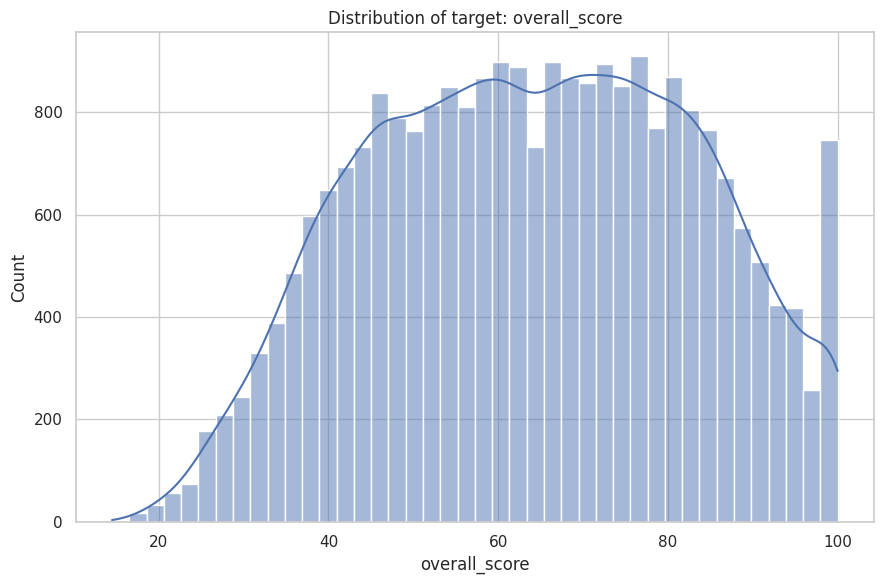

In [ ]:
#Detect Target Column Automatically
candidates = [c for c in df.columns if ('score' in c.lower()) or ('grade' in c.lower())]
print("Candidate target columns:", candidates)

# overall_score is the continuous outcome we want to predict (a combination of the
# subject scores plus attendance/study-habit effects), so it is preferred first.
preferred_order = ['overall_score', 'final_score', 'total_score']
target_col = None
for p in preferred_order:
    if p in df.columns:
        target_col = p
        break
if target_col is None and len(candidates)>0:
    target_col = candidates[0]

# If automatic detection fails, set target_col manually here
if target_col is None:
    raise SystemExit("Could not detect a target column automatically. Inspect df.columns and set target_col manually.")

print("Using target column:", target_col)

# Count missing targets
n_total = df.shape[0]
n_target_nan = df[target_col].isna().sum()
print(f"Rows total: {n_total}; rows with target NaN: {n_target_nan}")

# Distribution of target
plt.figure()
sns.histplot(df[target_col].dropna(), kde=True)
plt.title(f"Distribution of target: {target_col}")
plt.xlabel(target_col)
plt.tight_layout()
plt.show()


In [ ]:

# Drop rows with missing target (cannot train on missing labels)
if df[target_col].isna().sum() > 0:
    print("Dropping rows with missing target:", df[target_col].isna().sum())
    df = df.dropna(subset=[target_col]).reset_index(drop=True)
else:
    print("No missing targets.")

# Optional: drop obvious ID columns if present
id_like = [c for c in df.columns if c.lower() in ('id','index','userid','user_id','person_id','name','student_id')]
if id_like:
    print("Dropping ID-like columns:", id_like)
    df = df.drop(columns=id_like)

# Separate X and y
y = df[target_col]
X = df.drop(columns=[target_col]).copy()

# Drop leakage-prone columns: 'final_grade' is just a discretized/binned version of
# overall_score (e.g. 85-95 -> 'b', 70-85 -> 'c', ...), so keeping it as a feature
# would let the model "cheat" by reading the answer off a relabeled copy of itself.
leakage_cols = [c for c in ['final_grade'] if c in X.columns]
if leakage_cols:
    print("Dropping leakage-prone column(s):", leakage_cols)
    X = X.drop(columns=leakage_cols)

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object','category']).columns.tolist()
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Build preprocessing pipelines
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Fit preprocessor on X (used for transformation later)
preprocessor.fit(X)

# Build transformed feature names list (for feature selection mapping)
num_names = numeric_features
cat_names = []
if categorical_features:
    try:
        ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
        cat_names = list(ohe.get_feature_names_out(categorical_features))
    except Exception:
        # fallback if no categories or OHE unavailable
        cat_names = []
transformed_feature_names = num_names + cat_names
print("Transformed feature count:", len(transformed_feature_names))


No missing targets.
Dropping ID-like columns: ['student_id']
Dropping leakage-prone column(s): ['final_grade']
Numeric features: ['age', 'study_hours', 'attendance_percentage', 'math_score', 'science_score', 'english_score']
Categorical features: ['gender', 'school_type', 'parent_education', 'internet_access', 'travel_time', 'extra_activities', 'study_method']
Transformed feature count: 31


In [ ]:
#rain-Test Split & Pipeline Creation
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("Train/test shapes:", X_train.shape, X_test.shape)
print("Ensure no NaNs in y:", y_train.isna().sum(), y_test.isna().sum())

# Evaluation helper
def eval_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = math.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

# Baseline Ridge
pipe_ridge = Pipeline([('pre', preprocessor), ('model', Ridge(random_state=42))])
pipe_ridge.fit(X_train, y_train)
pred_ridge = pipe_ridge.predict(X_test)
ridge_baseline = eval_regression(y_test, pred_ridge)
print("Ridge baseline results:", ridge_baseline)

# Baseline RandomForest
pipe_rf = Pipeline([('pre', preprocessor), ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])
pipe_rf.fit(X_train, y_train)
pred_rf = pipe_rf.predict(X_test)
rf_baseline = eval_regression(y_test, pred_rf)
print("RandomForest baseline results:", rf_baseline)


Train/test shapes: (20000, 13) (5000, 13)
Ensure no NaNs in y: 0 0
Ridge baseline results: {'MSE': 17.072258576033587, 'RMSE': 4.131858973396065, 'MAE': 3.358136317128528, 'R2': 0.9529782128286999}
RandomForest baseline results: {'MSE': 10.200265701200003, 'RMSE': 3.1937854813997766, 'MAE': 2.2134460000000007, 'R2': 0.971905608109412}


In [ ]:
#Hyperparameter Tuning for Ridge Regression
print("Tuning Ridge (alpha) with GridSearchCV...")
param_grid_ridge = {'model__alpha': [0.01, 0.1, 1.0, 10.0]}
gs_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
gs_ridge.fit(X_train, y_train)
print("Ridge best params:", gs_ridge.best_params_, "best CV (neg MSE):", gs_ridge.best_score_)

print("\nTuning RandomForest with GridSearchCV")
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10],
    'model__min_samples_split': [2, 5]
}
gs_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=4, scoring='neg_mean_squared_error', n_jobs=-1)
gs_rf.fit(X_train, y_train)
print("RandomForest best params:", gs_rf.best_params_, "best CV (neg MSE):", gs_rf.best_score_)


Tuning Ridge (alpha) with GridSearchCV...
Ridge best params: {'model__alpha': 10.0} best CV (neg MSE): -16.679721170834583

Tuning RandomForest with GridSearchCV
RandomForest best params: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200} best CV (neg MSE): -9.534825932987502


In [ ]:

# Transform train/test to numeric matrices
X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)
if hasattr(X_train_trans, "toarray"):
    X_train_trans = X_train_trans.toarray()
    X_test_trans = X_test_trans.toarray()

# choose k features (cap at 12)
k = min(12, X_train_trans.shape[1])
print("Selecting top k =", k)

# SelectKBest (filter)
skb = SelectKBest(score_func=f_regression, k=k)
skb.fit(X_train_trans, y_train)
top_idx = np.argsort(skb.scores_)[-k:][::-1]
top_features = [transformed_feature_names[i] for i in top_idx]
print("Top features by SelectKBest:", top_features)

# RFE wrapper with RandomForest to cross-check
rfe_est = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rfe = RFE(rfe_est, n_features_to_select=k, step=0.1)
rfe.fit(X_train_trans, y_train)
rfe_selected = [name for name, sel in zip(transformed_feature_names, rfe.support_) if sel]
print("Top features by RFE:", rfe_selected)

# Intersection of both methods
selected_features = [f for f in top_features if f in rfe_selected]
if not selected_features:
    selected_features = top_features  # fallback if no intersection
print("Final selected features:", selected_features)

# Build selected matrices
selected_indices = [transformed_feature_names.index(f) for f in selected_features]
X_train_sel = X_train_trans[:, selected_indices]
X_test_sel = X_test_trans[:, selected_indices]
print("Selected feature matrices shapes:", X_train_sel.shape, X_test_sel.shape)


Selecting top k = 12
Top features by SelectKBest: ['study_hours', 'science_score', 'english_score', 'math_score', 'attendance_percentage', 'study_method_group study', 'parent_education_post graduate', 'parent_education_high school', 'study_method_coaching', 'study_method_online videos', 'gender_other', 'parent_education_diploma']
Top features by RFE: ['age', 'study_hours', 'attendance_percentage', 'math_score', 'science_score', 'english_score', 'gender_female', 'gender_other', 'school_type_private', 'travel_time_15-30 min', 'travel_time_<15 min', 'travel_time_>60 min']
Final selected features: ['study_hours', 'science_score', 'english_score', 'math_score', 'attendance_percentage', 'gender_other']
Selected feature matrices shapes: (20000, 6) (5000, 6)


In [ ]:
#Train Final Ridge Regression Model

# Ridge final
best_alpha = gs_ridge.best_params_['model__alpha']
final_ridge = Ridge(alpha=best_alpha, random_state=42)
final_ridge.fit(X_train_sel, y_train)
pred_ridge_final = final_ridge.predict(X_test_sel)
ridge_final_metrics = eval_regression(y_test, pred_ridge_final)
print("Final Ridge metrics:", ridge_final_metrics)

# RandomForest final
best_rf_params = gs_rf.best_params_
rf_kwargs = {
    'n_estimators': best_rf_params.get('model__n_estimators', 200),
    'max_depth': best_rf_params.get('model__max_depth', None),
    'min_samples_split': best_rf_params.get('model__min_samples_split', 2),
    'random_state': 42,
    'n_jobs': -1
}
final_rf = RandomForestRegressor(**rf_kwargs)
final_rf.fit(X_train_sel, y_train)
pred_rf_final = final_rf.predict(X_test_sel)
rf_final_metrics = eval_regression(y_test, pred_rf_final)
print("Final RandomForest metrics:", rf_final_metrics)

# Summary table
import pandas as pd
final_table = pd.DataFrame([
    ['Ridge (baseline)', ridge_baseline['RMSE'], ridge_baseline['R2']],
    ['RF (baseline)', rf_baseline['RMSE'], rf_baseline['R2']],
    ['Ridge (final)', ridge_final_metrics['RMSE'], ridge_final_metrics['R2']],
    ['RF (final)', rf_final_metrics['RMSE'], rf_final_metrics['R2']]
], columns=['Model','Test RMSE','Test R2'])
display(final_table)


Final Ridge metrics: {'MSE': 17.039369862481266, 'RMSE': 4.127877161748065, 'MAE': 3.354921784620872, 'R2': 0.953068797567802}
Final RandomForest metrics: {'MSE': 10.198445262899998, 'RMSE': 3.193500471723779, 'MAE': 2.2061198, 'R2': 0.9719106221069402}


,Model,Test RMSE,Test R2
0,Ridge (baseline),4.131859,0.952978
1,RF (baseline),3.193785,0.971906
2,Ridge (final),4.127877,0.953069
3,RF (final),3.193500,0.971911


Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 9.
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
MLP metrics: {'MSE': 17.33243183470614, 'RMSE': 4.163223731041383, 'MAE': 3.3735000465393066, 'R2': 0.9522616227218619}


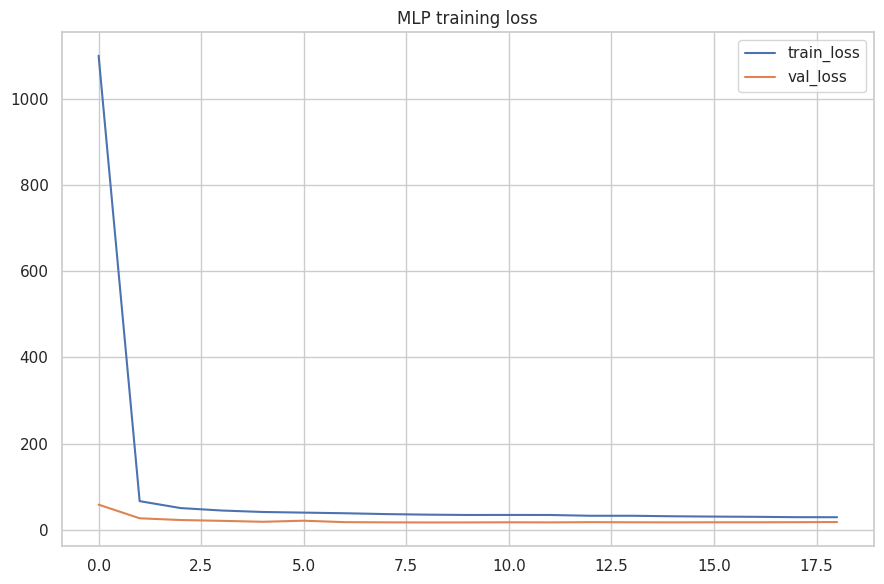

In [ ]:
#Neural Network Regression Model
scaler_sel = StandardScaler()
X_train_nn = scaler_sel.fit_transform(X_train_sel)
X_test_nn = scaler_sel.transform(X_test_sel)

def build_mlp(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(), 'mae'])
    return model

mlp = build_mlp(X_train_nn.shape[1])
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
history = mlp.fit(X_train_nn, y_train, validation_split=0.15, epochs=200, batch_size=32, callbacks=[es], verbose=0)

mlp_preds = mlp.predict(X_test_nn).ravel()
mlp_metrics = eval_regression(y_test, mlp_preds)
print("MLP metrics:", mlp_metrics)

# Plot training/validation loss
plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("MLP training loss")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:


# Feature importance from RandomForest (final)
feat_importances = pd.Series(final_rf.feature_importances_, index=selected_features).sort_values(ascending=False)
print("RandomForest feature importances:")
display(feat_importances)

# Permutation importance
perm = permutation_importance(final_rf, X_test_sel, y_test, n_repeats=20, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=selected_features).sort_values(ascending=False)
print("Permutation importances (mean):")
display(perm_imp)

# Save models and scaler
joblib.dump(final_ridge, "final_ridge.joblib")
joblib.dump(final_rf, "final_rf.joblib")
joblib.dump(scaler_sel, "scaler_selected.joblib")
mlp.save("final_mlp_model.keras")

# Save summary for report
summary = {
    'dataset_path': csv_path,
    'rows': int(df.shape[0]),
    'columns': int(df.shape[1]),
    'target': target_col,
    'selected_features': selected_features,
    'ridge_final_metrics': ridge_final_metrics,
    'rf_final_metrics': rf_final_metrics,
    'mlp_metrics': mlp_metrics,
    'ridge_best_params': gs_ridge.best_params_,
    'rf_best_params': gs_rf.best_params_,
    'saved_at_utc': datetime.utcnow().isoformat()
}
with open("project_summary_regression.json", "w") as f:
    json.dump(summary, f, indent=2)

# Save comparison CSV
final_table = pd.DataFrame([
    ['Ridge (baseline)', ridge_baseline['RMSE'], ridge_baseline['R2']],
    ['RF (baseline)', rf_baseline['RMSE'], rf_baseline['R2']],
    ['Ridge (final)', ridge_final_metrics['RMSE'], ridge_final_metrics['R2']],
    ['RF (final)', rf_final_metrics['RMSE'], rf_final_metrics['R2']],
    ['MLP (final)', mlp_metrics['RMSE'], mlp_metrics['R2']]
], columns=['Model','Test RMSE','Test R2'])
final_table.to_csv("model_comparison_regression.csv", index=False)

print("Saved models and summary files:")
print(" - final_ridge.joblib, final_rf.joblib, final_mlp_model.keras")
print(" - project_summary_regression.json, model_comparison_regression.csv")
display(final_table)


RandomForest feature importances:


,0
study_hours,0.744120
science_score,0.091303
math_score,0.064879
english_score,0.058137
attendance_percentage,0.040371
gender_other,0.001190


Permutation importances (mean):


,0
study_hours,0.830804
attendance_percentage,0.067309
science_score,0.057302
math_score,0.056912
english_score,0.056233
gender_other,0.000613


Saved models and summary files:
 - final_ridge.joblib, final_rf.joblib, final_mlp_model.keras
 - project_summary_regression.json, model_comparison_regression.csv


,Model,Test RMSE,Test R2
0,Ridge (baseline),4.131859,0.952978
1,RF (baseline),3.193785,0.971906
2,Ridge (final),4.127877,0.953069
3,RF (final),3.193500,0.971911
4,MLP (final),4.163224,0.952262
